In [104]:
import numpy as np
import math
import matplotlib.pyplot as plt

from scipy.special import erfc
import numpy as np

from tqdm import tqdm

# FUNZIONI

In [105]:
# ============================================================
# LITHIUM PARTICLE OBJECT
# ============================================================

class LiParticle:

    __slots__ = (
        "x",
        "y",
        "z",
        "r"
    )


    def __init__(self, x, y, z, r):

        self.x = x
        self.y = y
        self.z = z
        self.r = r



In [106]:

# ============================================================
# GRID INDEXING
# ============================================================

def get_index(x, y, z, nx, ny, nz):


    ix = int(x / cell_size)

    iy = int(y / cell_size)

    iz = int(z / cell_size)



    ix = max(0, min(ix, nx-1))

    iy = max(0, min(iy, ny-1))

    iz = max(0, min(iz, nz-1))


    return ix, iy, iz

In [107]:
# ============================================================
# OVERLAP CHECK
# ============================================================

def is_overlapping(
        x,
        y,
        z,
        r,
        cells,
        nx,
        ny,
        nz
):


    ix, iy, iz = get_index(
        x,
        y,
        z,
        nx,
        ny,
        nz
    )



    for dx_cell in (-1,0,1):

        for dy_cell in (-1,0,1):

            for dz_cell in (-1,0,1):


                jx = ix + dx_cell

                jy = iy + dy_cell

                jz = iz + dz_cell



                if (
                    jx < 0 or
                    jy < 0 or
                    jz < 0 or
                    jx >= nx or
                    jy >= ny or
                    jz >= nz
                ):
                    continue



                for p in cells[jx][jy][jz]:


                    distance2 = (
                        (x-p.x)**2 +
                        (y-p.y)**2 +
                        (z-p.z)**2
                    )


                    if distance2 < (r+p.r)**2:

                        return True



    return False

In [108]:
# ============================================================
# GRID CREATION
# ============================================================

def create_grid():


    nx = int(Lx/cell_size)

    ny = int(Ly/cell_size)

    nz = int(Lz/cell_size)



    cells = [
        [
            [
                []
                for _ in range(nz)
            ]
            for _ in range(ny)
        ]
        for _ in range(nx)
    ]


    return cells, nx, ny, nz

In [109]:
# ============================================================
# SATURATION DEPTH
# ============================================================

def calculate_saturation_depth(params):


    depth_list = np.arange(
        0,
        0.11 + dx,
        dx
    )


    Nd_vals = Ns * erfc(
        depth_list /
        (2*np.sqrt(D_Li * t_ann))
    )


    idx = np.where(
        Nd_vals <= Nd_saturation
    )[0]


    if len(idx) == 0:

        saturation_depth = depth_list[-1]

    else:

        saturation_depth = depth_list[idx[0]]

    #print(f"saturation depth {saturation_depth} cm")


    return saturation_depth

In [110]:
# ============================================================
# TRUNCATED POISSON
# ============================================================

def truncated_poisson(lam, Nmax):


    if Nmax <= 0:

        return 0


    for _ in range(100):

        n = np.random.poisson(lam)

        if n <= Nmax:

            return n


    return Nmax

In [480]:
# ============================================================
# GENERATE LITHIUM DISTRIBUTION
# ============================================================

def generate_lithium(params):


    print("")
    print("Generating Li distribution...")
    #print(f"alpha {params['alpha']:.2e}")


    saturation_depth = calculate_saturation_depth(params)


    print(
        "Saturation depth =",
        saturation_depth*10,
        "mm"
    )



    cells, nx, ny, nz = create_grid()



    particles_x = []

    particles_y = []

    particles_z = []

    particles_per_slice = []



    x_slices = np.arange(
        0,
        saturation_depth,
        dx
    )


    total_particles = 0



    V_particle = (
        4/3 *
        math.pi *
        r_Li**3
    )



    for xi in tqdm(
        x_slices,
        desc="Li slices"
    ):



        # Li concentration profile

        Nd_val = Ns * erfc(
            xi /
            (
                2*np.sqrt(
                    D_Li *
                    t_ann
                )
            )
        )



        density = (

            alpha *

            max(
                Nd_val - Nd_saturation,
                0
            )
        )



        V_slice = dx*Ly*Lz


        lam = density*V_slice



        # maximum packing

        #pf = 0.64
        pf = 1

        V_particle = 4/3 * np.pi * r_Li**3
        
        Nmax = int(
            pf *
            V_slice /
            V_particle
        )



        N_i = truncated_poisson(
            lam,
            Nmax
        )




        accepted = 0

        attempts = 0


        max_attempts = max(
            100,
            N_i*200
        )



        while (
            accepted < N_i and
            attempts < max_attempts
        ):


            attempts += 1



            x = (
                xi +
                np.random.random()*dx
            )


            y = (
                np.random.random()*Ly
            )


            z = (
                np.random.random()*Lz
            )



            if not is_overlapping(
                x,
                y,
                z,
                r_Li,
                cells,
                nx,
                ny,
                nz
            ):



                ix, iy, iz = get_index(
                    x,
                    y,
                    z,
                    nx,
                    ny,
                    nz
                )



                p = LiParticle(
                    x,
                    y,
                    z,
                    r_Li
                )


                cells[ix][iy][iz].append(p)



                particles_x.append(x)

                particles_y.append(y)

                particles_z.append(z)



                accepted += 1

                total_particles += 1


        particles_per_slice.append({
            "x": xi,
            "N_target": N_i,
            "N_accepted": accepted,
            "density": density
        })


    
    print(
        "Total Li particles =",
        total_particles
    )



    particles_x = np.array(
        particles_x
    )


    particles_y = np.array(
        particles_y
    )


    particles_z = np.array(
        particles_z
    )



    return (

        cells,

        saturation_depth,

        particles_x,

        particles_y,

        particles_z,

        particles_per_slice            

    )



# INIZIO

In [481]:
# ============================================================
# GEOMETRY
# ============================================================

Lx = 0.2
Ly = 0.2
Lz = 0.2

dx = 0.001       # cm = 10 um


# ============================================================
# REFERENCE Li PRECIPITATE
# ============================================================

r0 = 0.002       # cm = 20 um

V0 = (4/3) * np.pi * r0**3

r_Li = r0      # cm

cell_size =  2 * r_Li


# ============================================================
# ANNEALING
# ============================================================

R = 1.98
H = 11800
D0 = 2.5e-3

Nd_saturation = 1e14


# ============================================================
# PARAMETERS
# ============================================================

T_ann = 623      # K
t_ann = 18*60     
alpha = 1.6e-9   # <-- metti il tuo valore


Ns = 10**(
    21.27 - 2610/T_ann
)

D_Li = D0 * np.exp(
    -H/(R*T_ann)
)

print("Ns   =", Ns)
print("D_Li =", D_Li)
print("r0   =", r0*1e4, "um")

Ns   = 1.2039096635950326e+17
D_Li = 1.7518396803995296e-07
r0   = 20.0 um


In [482]:
depth = np.arange(
    0,
    0.11 + dx,
    dx
)


Nd = Ns * erfc(
    depth /
    (
        2*np.sqrt(
            D_Li * t_ann
        )
    )
)
print("max Nd   =", np.max(Nd))


max Nd   = 1.2039096635950326e+17


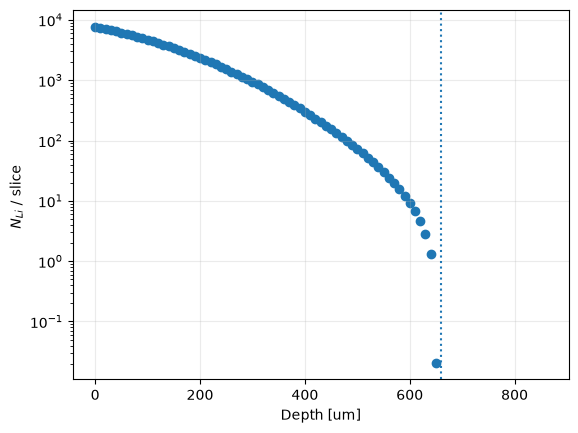

122909.88651405985


In [483]:
plt.figure()
N = alpha * (Nd[Nd>1e12] - Nd_saturation) * dx * Ly *Lz
plt.scatter(
    depth[Nd>1e12]*1e4,
    N 
)


plt.axvline(660,
          linestyle = ":")

plt.xlabel("Depth [um]")
plt.ylabel(r"$N_{Li}$ / slice ")

plt.grid(alpha = 0.25)
plt.yscale('log')
plt.show()

print(f"{sum(N)}")

In [484]:
N_charges = 15
N_repeat = 15
FCCD = 0.085
output = 'library'

In [485]:
params = [1,
          N_charges,
          N_repeat,
          alpha,
          FCCD,
          T_ann,
          t_ann,
          output
         ]

In [487]:
cells, saturation_depth, px, py, pz, particles_per_slice = generate_lithium(params)


Generating Li distribution...
Saturation depth = 0.66 mm


Li slices: 100%|██████████| 66/66 [01:03<00:00,  1.04it/s]

Total Li particles = 24716


# CHECK OVERLAP

In [488]:
from scipy.spatial import cKDTree
import numpy as np


def check_overlaps(px, py, pz, r):

    positions = np.column_stack(
        (px, py, pz)
    )

    tree = cKDTree(positions)

    pairs = tree.query_pairs(
        2 * r
    )

    print(
        "Number of overlapping pairs =",
        len(pairs)
    )

    if len(pairs) == 0:

        print("✓ No overlapping particles")

    else:

        print("⚠ Overlap detected")

        for i, j in list(pairs)[:10]:

            distance = np.linalg.norm(
                positions[i] - positions[j]
            )

            print(
                f"particles {i} - {j}: "
                f"d = {distance:.3f} µm"
            )

    return pairs

In [489]:
from scipy.spatial import cKDTree
import numpy as np


def check_contacts(px, py, pz, r, tolerance=1e-8):

    positions = np.column_stack((px, py, pz))

    tree = cKDTree(positions)

    diameter = 2 * r

    # Cerchiamo tutte le coppie che possono essere
    # in overlap o contatto
    pairs = tree.query_pairs(diameter + tolerance)

    overlaps = []
    contacts = []

    for i, j in pairs:

        distance = np.linalg.norm(
            positions[i] - positions[j]
        )

        # OVERLAP
        if distance < diameter - tolerance:

            overlaps.append((i, j, distance))

        # CONTACT
        elif abs(distance - diameter) <= tolerance:

            contacts.append((i, j, distance))

    print(f"Diameter = {diameter:.6f} µm")
    print(f"Overlap pairs = {len(overlaps)}")
    print(f"Contact pairs = {len(contacts)}")

    # Mostra overlap
    if overlaps:

        print("\n⚠ OVERLAPS:")

        for i, j, distance in overlaps[:10]:

            print(
                f"particles {i} - {j}: "
                f"d = {distance:.6f} µm"
            )

    # Mostra contatti
    if contacts:

        print("\n✓ CONTACTS:")

        for i, j, distance in contacts[:10]:

            print(
                f"particles {i} - {j}: "
                f"d = {distance:.6f} µm"
            )

    return overlaps, contacts

In [490]:
pairs = check_overlaps(
    px,
    py,
    pz,
    r_Li
)
pairs = check_contacts(
    px,
    py,
    pz,
    r_Li
)

Number of overlapping pairs = 0
✓ No overlapping particles
Diameter = 0.004000 µm
Overlap pairs = 0
Contact pairs = 0


# Come generarli vicini?

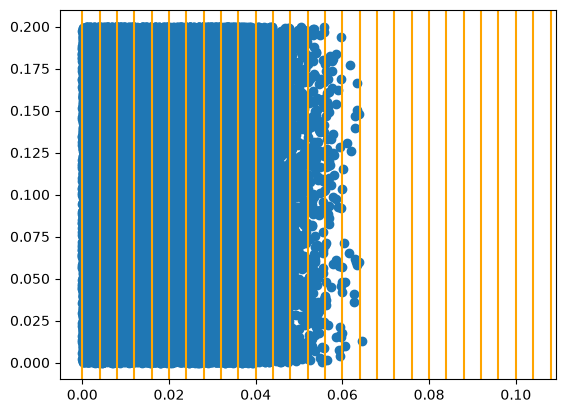

In [491]:
plt.scatter(px,py)
slices = np.arange(depth.min(), depth.max(), 2*r_Li)
for s in slices:
    plt.axvline(s, color = 'orange')

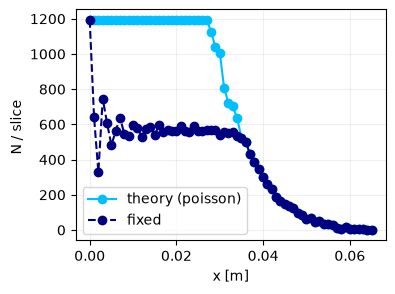

In [492]:
x = np.array([
    d["x"] for d in particles_per_slice
])

N_target = np.array([
    d["N_target"] for d in particles_per_slice
])

N_accepted = np.array([
    d["N_accepted"] for d in particles_per_slice
])

plt.figure(figsize = (4,3))
plt.plot(x, N_target, color = 'deepskyblue', marker="o", label = 'theory (poisson)', )
plt.plot(x, N_accepted, color = 'navy', marker="o", ls = '--', label  = 'fixed')
plt.xlabel("x [m]")
plt.ylabel("N / slice ")
plt.grid(alpha = 0.2)
plt.legend()
plt.show()

In [493]:

px_s1 = px[px < 2*r_Li]
py_s1 = py[py < 2*r_Li]
pz_s1 = pz[pz < 2*r_Li]

In [494]:
particles_per_slice

[{'x': np.float64(0.0),
  'N_target': 1193,
  'N_accepted': 1193,
  'density': np.float64(192465546.17520523)},
 {'x': np.float64(0.001),
  'N_target': 1193,
  'N_accepted': 643,
  'density': np.float64(184568064.3272219)},
 {'x': np.float64(0.002),
  'N_target': 1193,
  'N_accepted': 328,
  'density': np.float64(176691421.21044815)},
 {'x': np.float64(0.003),
  'N_target': 1193,
  'N_accepted': 747,
  'density': np.float64(168856290.74250963)},
 {'x': np.float64(0.004),
  'N_target': 1193,
  'N_accepted': 608,
  'density': np.float64(161083019.38447294)},
 {'x': np.float64(0.005),
  'N_target': 1193,
  'N_accepted': 482,
  'density': np.float64(153391467.7991007)},
 {'x': np.float64(0.006),
  'N_target': 1193,
  'N_accepted': 563,
  'density': np.float64(145800858.86193198)},
 {'x': np.float64(0.007),
  'N_target': 1193,
  'N_accepted': 639,
  'density': np.float64(138329633.9605796)},
 {'x': np.float64(0.008),
  'N_target': 1193,
  'N_accepted': 544,
  'density': np.float64(130995319

In [495]:
def V_sphere(r):
    return (4/3) * np.pi * (r**3)

In [496]:
rs

array([ 20,  40,  60,  80, 100])

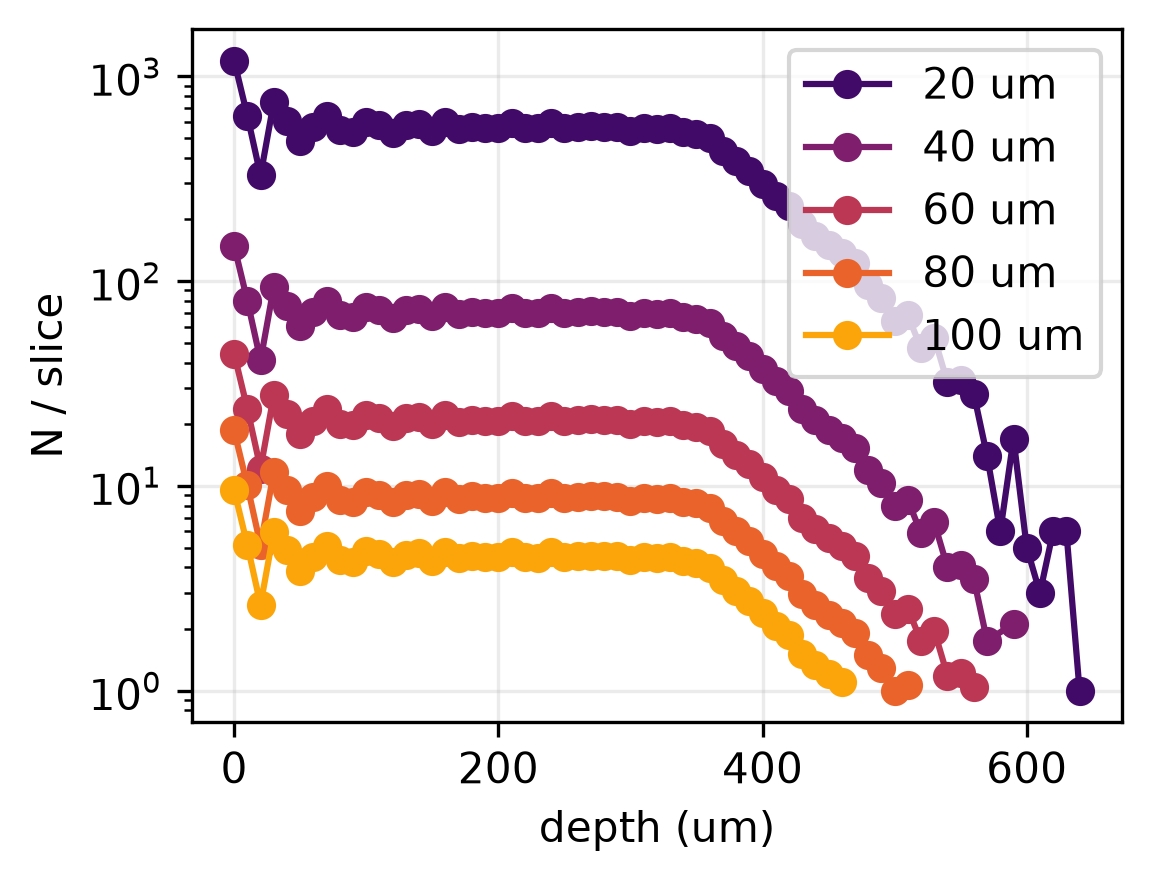

In [516]:
N_accepted = np.array([
    d["N_accepted"] for d in particles_per_slice
])

rs = np.arange(20, 120, 20)
V_20 = V_sphere(20)

colors = plt.colormaps["inferno"](
    np.linspace(0.2, 0.8, len(rs))
)

N_big = []
plt.figure(figsize = (4,3))
for i, r in enumerate(rs):
    V = V_sphere(r)
    N = N_accepted * V_20 / V
    plt.plot(x[N>=1]*1e4, N[N>=1], color = colors[i], marker = 'o', label = f'{r} um')
    plt.ylabel('N / slice')
    plt.xlabel('depth (um)')
    plt.yscale('log')
    plt.legend()
    plt.grid(alpha = 0.25)

    N_big.append({
            "r": r,
            "x": x,
            "N": N,
        })
    

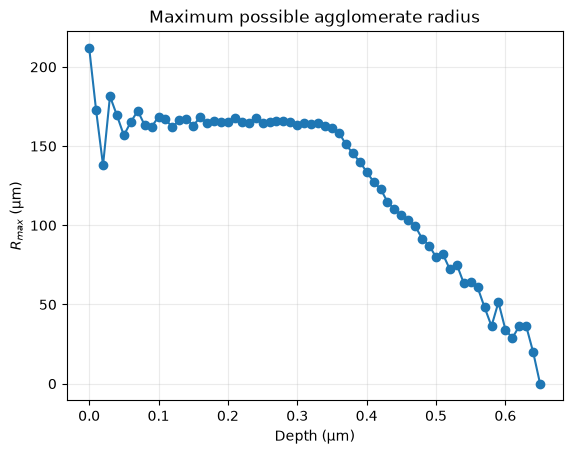

In [521]:
r0 = 20  # um

N_small = np.array([
    d["N_accepted"] for d in particles_per_slice
])

x = np.array([
    d["x"] for d in particles_per_slice
])

R_max = r0 * N_small**(1/3)

plt.figure()

plt.plot(
    x*10,
    R_max,
    marker="o"
)

plt.xlabel("Depth (µm)")
plt.ylabel(r"$R_{max}$ (µm)")
plt.title("Maximum possible agglomerate radius")
plt.grid(alpha=0.25)

plt.show()

In [524]:
# ============================================================
# MAXIMUM NUMBER OF AGGLOMERATES
# ============================================================

N_clusters = np.zeros(
    (len(radii), len(x))
)

for i, k in enumerate(required_particles):

    N_clusters[i, :] = np.floor(
        N_small / k
    )

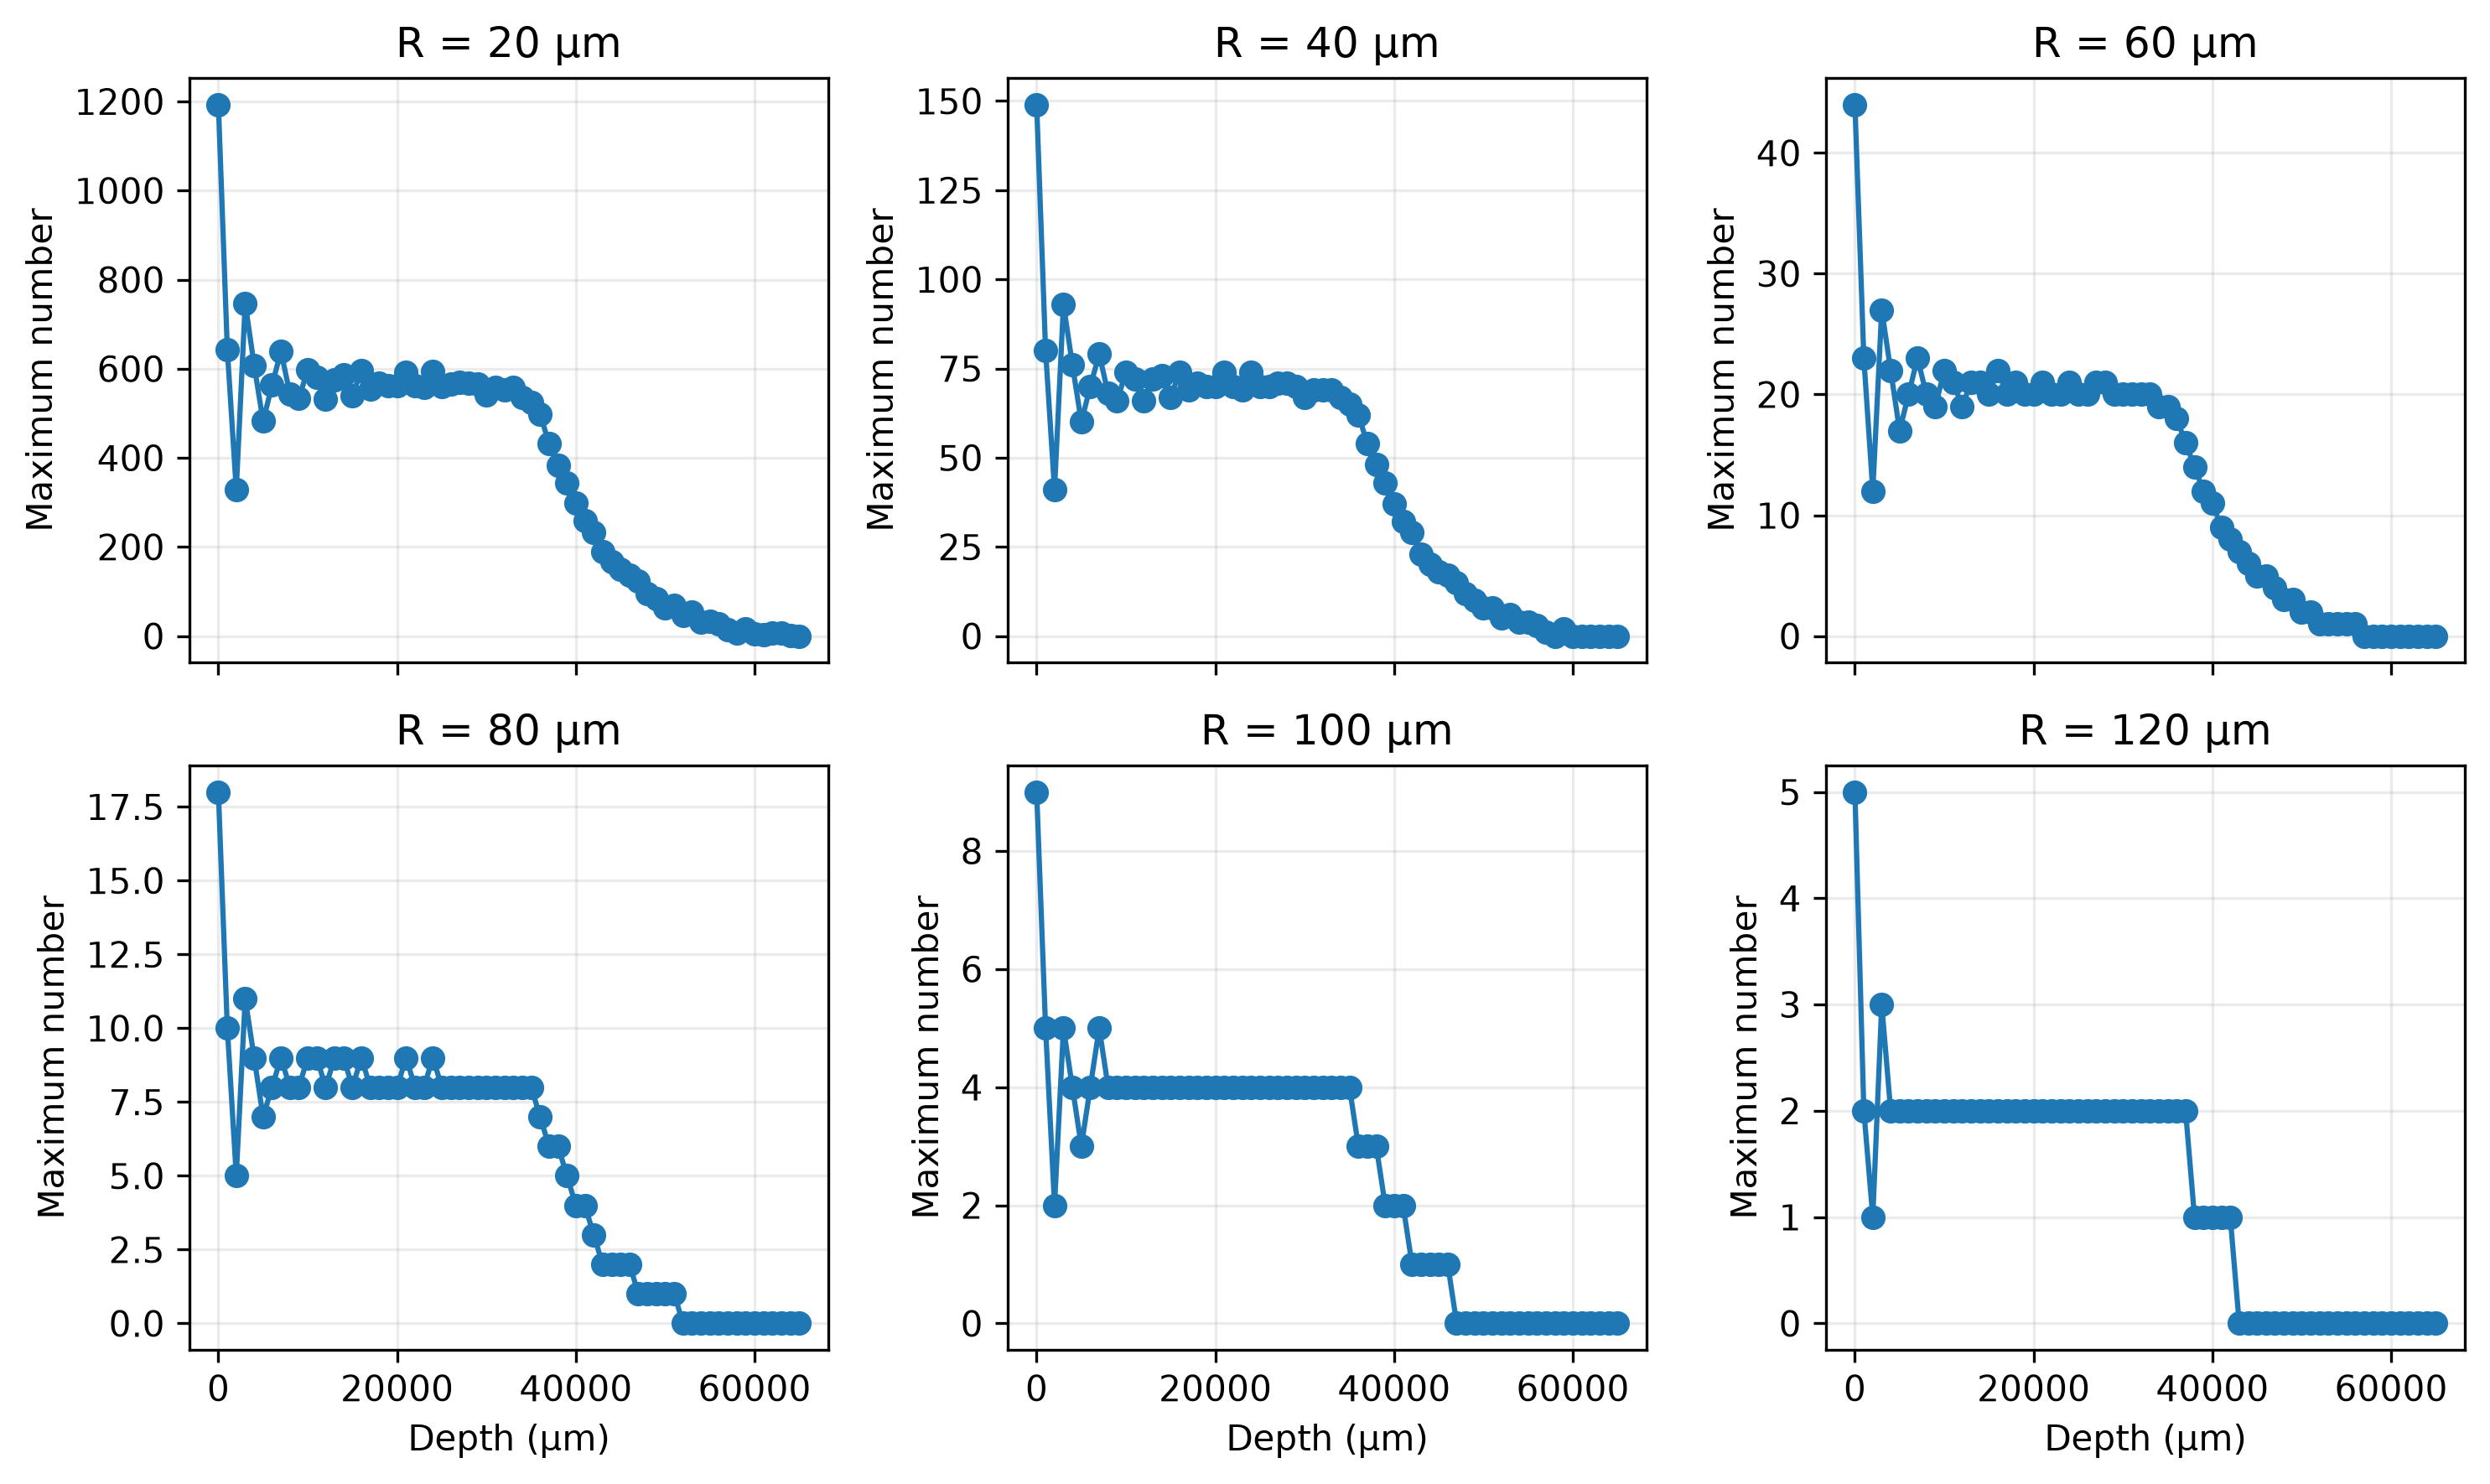

In [536]:
n = len(radii)

ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(10, 3 * nrows),
    sharex=True,
    dpi = 300
)

axes = np.atleast_1d(axes).flatten()

for i, r in enumerate(radii):

    axes[i].plot(
        x * 1e6,
        N_clusters[i],
        marker="o"
    )

    axes[i].set_title(f"R = {r} µm")
    axes[i].set_ylabel("Maximum number")
    axes[i].grid(alpha=0.25)

    if i >= n - ncols:
        axes[i].set_xlabel("Depth (µm)")

# Nasconde eventuali subplot vuoti
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()

# P(R|x)

In [543]:
r0 = 20.0  # µm

radii = np.arange(20, 121, 5)

k_required = np.floor(
    (radii / r0)**3
).astype(int)

print(
    np.column_stack([
        radii,
        k_required
    ])
)

[[ 20   1]
 [ 25   1]
 [ 30   3]
 [ 35   5]
 [ 40   8]
 [ 45  11]
 [ 50  15]
 [ 55  20]
 [ 60  27]
 [ 65  34]
 [ 70  42]
 [ 75  52]
 [ 80  64]
 [ 85  76]
 [ 90  91]
 [ 95 107]
 [100 125]
 [105 144]
 [110 166]
 [115 190]
 [120 216]]


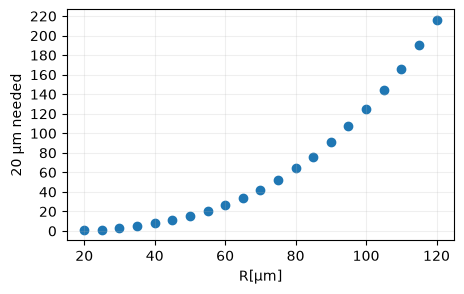

In [544]:
plt.figure(figsize=(5,3))
plt.scatter(radii, k_required, label=f'x = {x[j]:.1f}')

plt.yticks(np.arange(0, max(k_required) + 10, 20))

plt.xlabel('R[µm]')
plt.ylabel('20 µm needed')
plt.grid(alpha = 0.2)

plt.show()

In [545]:
k_required

array([  1,   1,   3,   5,   8,  11,  15,  20,  27,  34,  42,  52,  64,
        76,  91, 107, 125, 144, 166, 190, 216])

In [568]:
N20 = N_clusters[N_clusters>0] [0]
v20 =  N20 * 4/3 * np.pi * 20**3
a20 = np.pi * 20**2
v120 = 4/3 * np.pi * 120**3
a120 = np.pi * 120**2

n =  v20 / v120

f = n * a120 / (N_clusters[N_clusters>0] [0] * a20)

In [592]:
fv

array([0.0838223 , 0.0838223 , 0.02794077, 0.01676446, 0.01047779,
       0.00762021, 0.00558815, 0.00419111, 0.00310453, 0.00246536,
       0.00199577, 0.00161197, 0.00130972, 0.00110292, 0.00092112,
       0.00078339, 0.00067058, 0.0005821 , 0.00050495, 0.00044117,
       0.00038807])

In [593]:
( n * v )

np.float64(39977813.71448132)

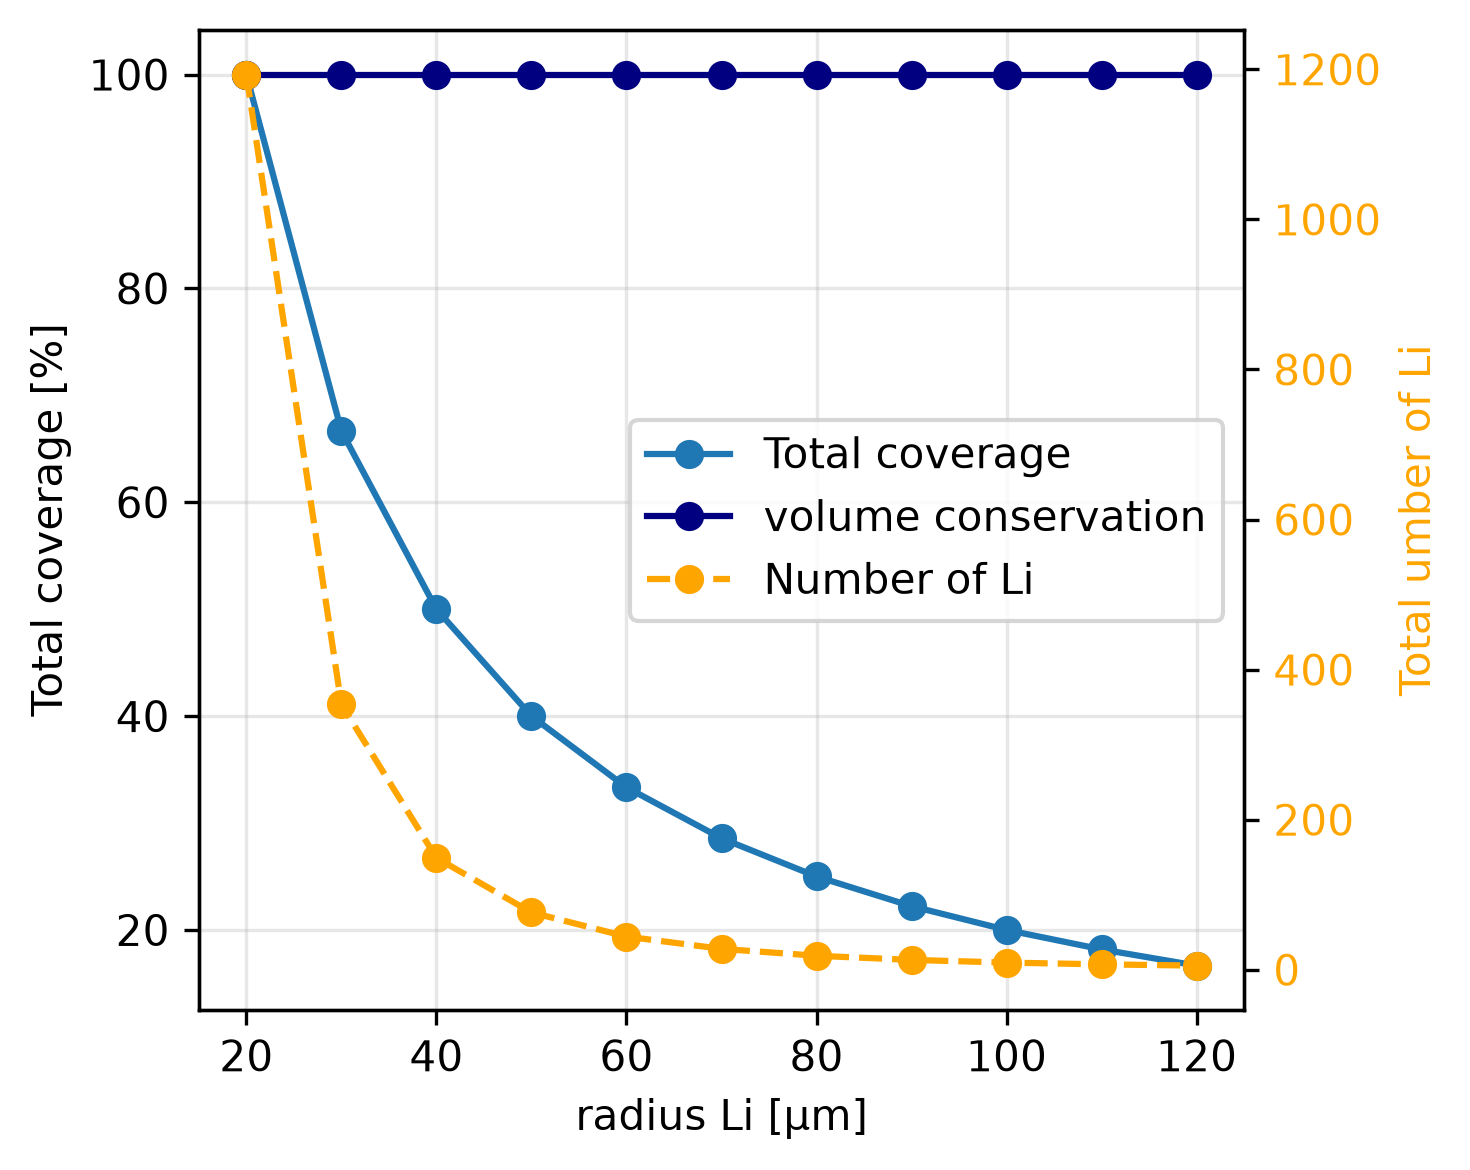

In [601]:
f_arr = []

N20 = N_clusters[N_clusters > 0][0]
v20 = N20 * 4/3 * np.pi * 20**3

for i,r in enumerate(radii):
     # volume di una sfera grande
    v = 4/3 * np.pi * r**3

    # area geometrica di una sfera grande
    a = np.pi * r**2

    # numero equivalente di sfere grandi
    n = v20 / v

    # copertura superficiale relativa
    f = 100 * n * a / (N20 * a20)

    # copertura volumica
    fv = 100 * (n * v) / v20

    # SALVA I RISULTATI
    f_arr.append({
        "r": r,
        "f": f,
        "fv": fv,
        "n": n
    })

r_arr = [x["r"] for x in f_arr]
f_values = [x["f"] for x in f_arr]
fv_values = [x["fv"] for x in f_arr]
n_values = [x["n"] for x in f_arr]


# ============================================================
# PLOT
# ============================================================

fig, ax1 = plt.subplots(figsize=(5, 4), dpi  = 300)

# Asse sinistro: coverage
ax1.plot(
    r_arr,
    f_values,
    'o-',
    label='Total coverage'
)

ax1.plot(
    r_arr,
    fv_values,
    'o-',
    color = 'navy',
    label = 'volume conservation'
    
)

ax1.set_xlabel("radius Li [µm]")
ax1.set_ylabel("Total coverage [%]")
ax1.grid(alpha=0.3)


# Asse destro: numero di Li
ax2 = ax1.twinx()

ax2.plot(
    r_arr,
    n_values,
    'o--',
    color='orange',
    label='Number of Li'
)

ax2.set_ylabel(
    "Total umber of Li",
    color='orange'
)

ax2.tick_params(
    axis='y',
    labelcolor='orange'
)


# Legenda combinata
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='best'
)

plt.tight_layout()
plt.show()

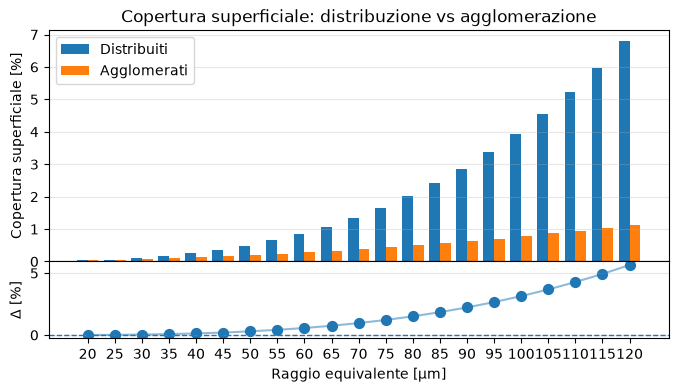

In [607]:
import numpy as np
import matplotlib.pyplot as plt


# NON HA ASSOLUTAMENTE SENSO


# Dimensione superficie
A_slice = 2000 * 2000  # µm²

# Raggi
radii = np.arange(20, 121, 5)

# Numero di primari necessari
N = (radii / 20.0)**3

# -----------------------------
# Copertura: distribuiti
# -----------------------------
A_uniform = N * np.pi * 20.0**2
coverage_uniform = A_uniform / A_slice * 100

# -----------------------------
# Copertura: agglomerato
# -----------------------------
A_agg = np.pi * radii**2
coverage_agg = A_agg / A_slice * 100

# Differenza
coverage_difference = coverage_uniform - coverage_agg


# ==========================================
# FIGURA
# ==========================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 4),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# ------------------------------------------
# PLOT SUPERIORE: BAR
# ------------------------------------------

width = 0.4
x_pos = np.arange(len(radii))

ax1.bar(
    x_pos - width/2,
    coverage_uniform,
    width,
    label='Distribuiti'
)

ax1.bar(
    x_pos + width/2,
    coverage_agg,
    width,
    label='Agglomerati'
)

ax1.set_ylabel('Copertura superficiale [%]')
ax1.set_title('Copertura superficiale: distribuzione vs agglomerazione')
ax1.legend()

ax1.grid(axis='y', alpha=0.3)


# ------------------------------------------
# PLOT INFERIORE: DIFFERENZA
# ------------------------------------------

ax2.scatter(
    x_pos,
    coverage_difference,
    s=50
)

ax2.plot(
    x_pos,
    coverage_difference,
    alpha=0.5
)

ax2.axhline(
    0,
    linestyle='--',
    linewidth=1
)

ax2.set_ylabel(r'$\Delta$ [%]')
ax2.set_xlabel('Raggio equivalente [µm]')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(radii)

ax2.grid(axis='y', alpha=0.3)


# Nessuno spazio verticale
plt.subplots_adjust(hspace=0)

plt.show()

array([1.193e+03, 6.430e+02, 3.280e+02, 7.470e+02, 6.080e+02, 4.820e+02,
       5.630e+02, 6.390e+02, 5.440e+02, 5.330e+02, 5.980e+02, 5.800e+02,
       5.310e+02, 5.760e+02, 5.860e+02, 5.400e+02, 5.960e+02, 5.550e+02,
       5.680e+02, 5.610e+02, 5.610e+02, 5.920e+02, 5.610e+02, 5.580e+02,
       5.930e+02, 5.600e+02, 5.650e+02, 5.700e+02, 5.680e+02, 5.660e+02,
       5.420e+02, 5.590e+02, 5.530e+02, 5.590e+02, 5.360e+02, 5.250e+02,
       4.980e+02, 4.320e+02, 3.840e+02, 3.440e+02, 2.990e+02, 2.590e+02,
       2.330e+02, 1.890e+02, 1.670e+02, 1.500e+02, 1.370e+02, 1.230e+02,
       9.600e+01, 8.300e+01, 6.400e+01, 6.800e+01, 4.700e+01, 5.300e+01,
       3.200e+01, 3.300e+01, 2.800e+01, 1.400e+01, 6.000e+00, 1.700e+01,
       5.000e+00, 3.000e+00, 6.000e+00, 6.000e+00, 1.000e+00, 0.000e+00])

In [632]:
P = np.zeros((len(radii), len(x)))

N20 = N_clusters[0]

k = (radii / r0)**3

N_target_agg = 4
sigma = 20

for j in range(len(x)):

    N = N20[j]

    # ==========================================
    # Quanti agglomerati posso produrre
    # ==========================================

    n_agg = N / k

    # ==========================================
    # Numero target di agglomerati
    # ==========================================

    N_agg_target = min(N, N_target_agg)

    # ==========================================
    # Raggio che conserva il volume
    # ==========================================

    R_target = r0 * (
        N / N_agg_target
    )**(1/3)

    # ==========================================
    # Raggi fisicamente possibili
    # ==========================================

    possible = n_agg >= 1

    # ==========================================
    # Preferenza per R_target
    # ==========================================

    preference = np.exp(
        -0.5 *
        ((radii - R_target) / sigma)**2
    )

    # ==========================================
    # Peso
    # ==========================================

    weights = np.zeros(len(radii))

    weights[possible] = preference[possible]

    # ==========================================
    # Normalizzazione
    # ==========================================

    total = weights.sum()

    if total > 0:
        P[:, j] = weights / total

/tmp/ipykernel_72295/1385057220.py:31: RuntimeWarning: invalid value encountered in scalar divide
  N / N_agg_target


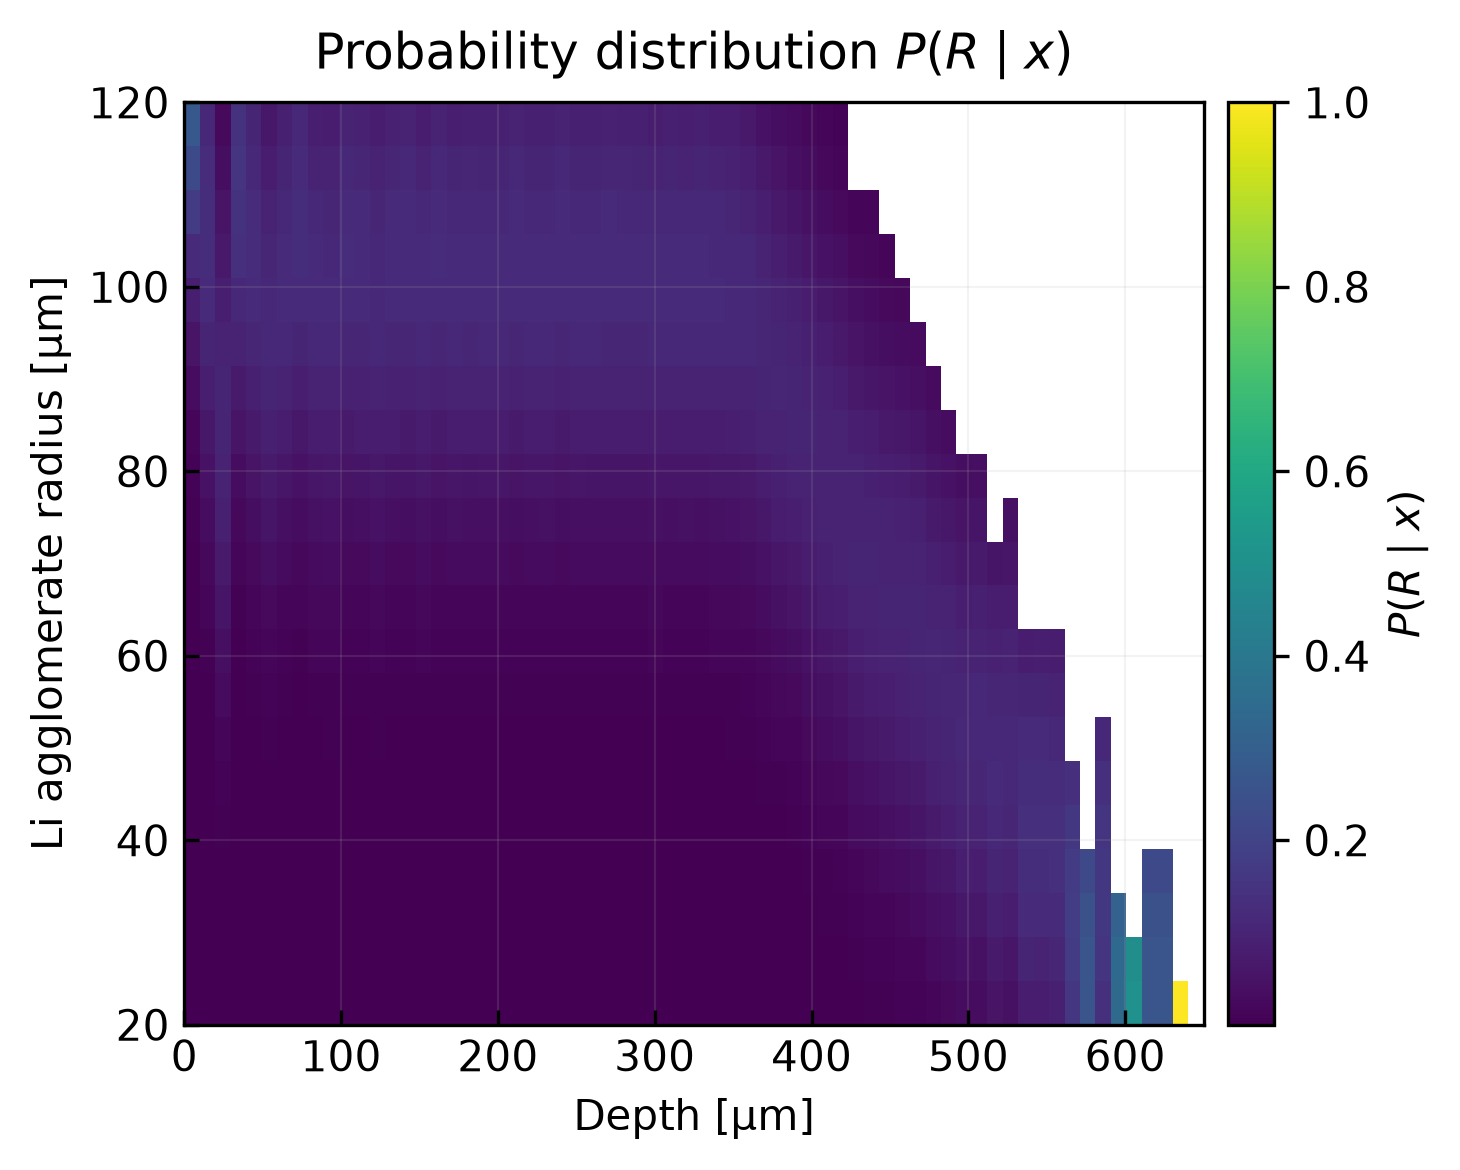

In [639]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

# ------------------------------------------------------------
# Colormap: valori zero in bianco
# ------------------------------------------------------------

cmap = plt.cm.viridis.copy()
cmap.set_under("white")

# Valori > 0 vengono colorati
positive = P[P > 0]

vmin = positive.min() if len(positive) > 0 else 1e-10

norm = Normalize(
    vmin=vmin,
    vmax=P.max()
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

im = ax.imshow(
    P,
    aspect="auto",
    origin="lower",
    extent=[
        x[0] * 10000,
        x[-1] * 10000,
        radii[0],
        radii[-1]
    ],
    interpolation="nearest",
    cmap=cmap,
    norm=norm
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel("Depth [µm]")
ax.set_ylabel("Li agglomerate radius [µm]")

ax.set_title(
    r"Probability distribution $P(R\mid x)$",
    pad=8
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02
)

cbar.set_label(r"$P(R\mid x)$")

# ------------------------------------------------------------
# Grid leggera
# ------------------------------------------------------------

ax.tick_params(direction="in")
ax.grid(
    alpha=0.15,
    linewidth=0.5
)

plt.tight_layout()
plt.show()

In [634]:
x_um = x * 1e4  # x è in cm
x_um

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
       220., 230., 240., 250., 260., 270., 280., 290., 300., 310., 320.,
       330., 340., 350., 360., 370., 380., 390., 400., 410., 420., 430.,
       440., 450., 460., 470., 480., 490., 500., 510., 520., 530., 540.,
       550., 560., 570., 580., 590., 600., 610., 620., 630., 640., 650.])

In [635]:
radii

array([ 20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,  75,  80,
        85,  90,  95, 100, 105, 110, 115, 120])

In [ ]:
n = len(x_um)

# Numero di colonne desiderato
ncols = 8
nrows = int(np.ceil(n / ncols))
colors = plt.colormaps["inferno"](
    np.linspace(0.2, 0.8, n)
)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4 * ncols, 3.5 * nrows),
    squeeze=False,
    dpi = 300
)

axes = axes.flatten()

for j, ax in enumerate(axes[:n]):

    ax.hist(
        radii,
        bins=len(radii),
        weights=P[:, j],
        color = colors[j]
    )

    ax.set_xlabel("R (µm)")
    ax.set_ylabel(r"$P(R|x)$")

    ax.set_title(
        f"x = {x_um[j]:.0f} µm"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

# Nasconde eventuali subplot vuoti
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("DISTR.png")